# Exploratory Data Analysis: Association Analysis Between Numerical and Categorical

Examining the relationship between variables can give us key insight into our data. 

In this lesson, we will 2 ways of assessing the association between a quantitative variable and a categorical variable:
* Numerical way
* Graphical way

In the next few exercises, we’ll explore a dataset that contains demographic information and other characteristics for each student:

In [ ]:
import pandas as pd
students = pd.read_csv("students.csv")

In [ ]:
students.head()

| |school|address|absences|Mjob|Fjob|G3|
|---|---|---|---|---|---|---|
|0|	GP	|U	|6	|at_home|	teacher|	6|
|1|	GP	|U	|4	|at_home|	other|	6
|2|GP	|U	|10	|at_home|	other|	10|
|3|	GP	|U	|2	|health|	services|	15|
|4|	GP	|U	|4	|other|	other|	10|

## Numerical way of Association Analysis

Mean and median differences are summary statistics that can be used to assess an association between a quantitative variable and a categorical variable.

We can examine the difference of means of 2 groups and the difference of median of 2 groups:
* If the difference is highly significant (Big), then it indicates there is a strong assoication between the numerical variable and the categorical variable
* If the difference is not significant (small), then it indicates there is a week assoication between the numerical variable and the categorical variable

Example: Suppose we want to know: Is a student’s score (G3) associated with their school (school)? Maybe students at one of the schools consistently score higher than students at the other school.

We can start by finding the mean math score for students at each school. We can then find the difference between them:

In [ ]:
score_GP_mean = students.G3[students.school="GP"].mean()
score_MS_mean = students.MS[students.school="MS"].mean()

#Mean difference
mean_diff = score_GP_mean-score_MS_mean

#Output: 0.64

In [ ]:
score_GP_median = students.G3[students.school="GP"].median()
score_MS_median = students.MS[students.school="MS"].median()

#Median difference
median_diff = score_GP_median-score_MS_median

#Output: 1.0

## Graphical way of Association Analysis

The difference in mean math scores for students at GP and MS was 0.64.

How do we know whether this difference is considered small or large? To answer this question, we need to know something about the spread of the data.

To get a better sense of spread is by looking at a visual representation of the data, we are going to go over 2 examples of visualization:
* Side-by-side boxplot
* Overlapping histogram

### Boxplot

Side-by-side box plots are useful in visualizing mean and median differences because they allow us to visually estimate the variation in the data. 

This can help us determine if mean or median differences are “large” or “small”.

To create a side-by-side boxplot:

syntax:

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="categorical_data_column", 
    y="numerical_data_column", 
    data=data_name
)
plt.show()
plt.close()

Let’s take a look at side by side boxplots of math scores(G3) at each school:

In [ ]:
import seaborn as sns
import matplot.pyplot as plt

sns.boxplot(
    x="school",
    y="G3",
    data=students
)
plt.show()
plt.close()

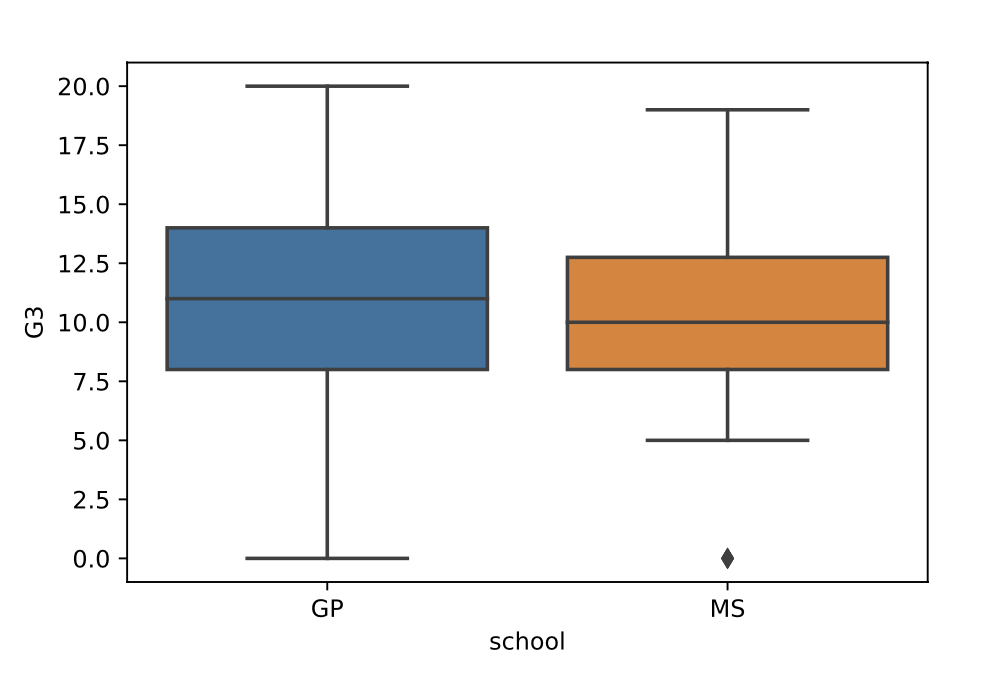

Looking at the plot, we can clearly see that there is a lot of overlap between the boxes (i.e. the middle 50% of the data). Therefore, we can be more confident that there is not much difference between the math scores of the two groups. As the result, location of school (urban or rural) has no influence on the math score (G3) of each student.

In contrast, suppose we saw the following plot:

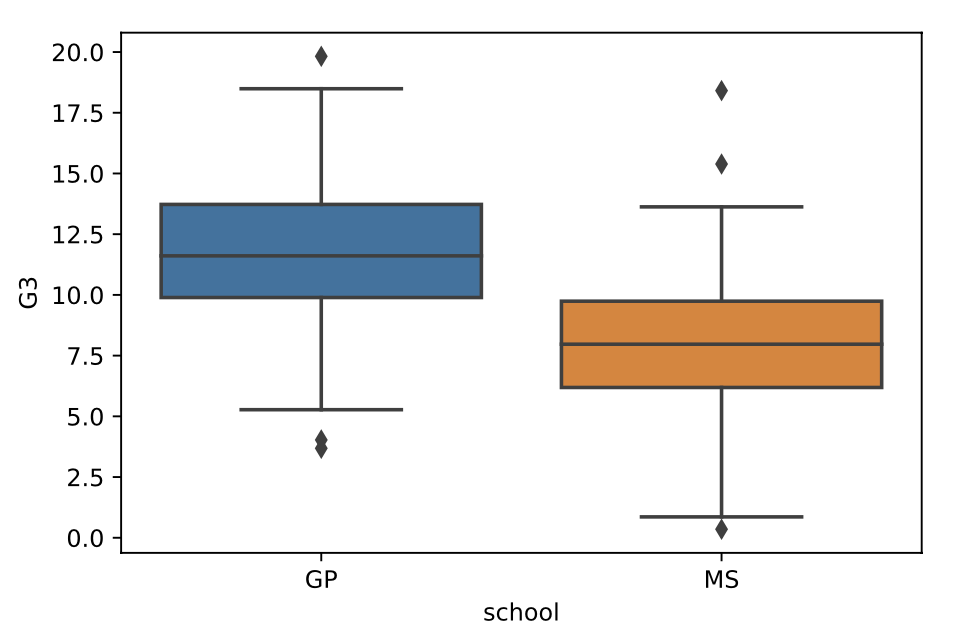

In this version, the boxes barely overlap, demonstrating that the middle 50% of scores are different for the two schools. This would be evidence of a stronger association between school and math score. As the result, overall GP school student obtain higher math score (G3) than student in MS school.

### Overlapping Histogram

Another way to explore the relationship between a quantitative and categorical variable in more detail is by inspecting overlapping histogram.

To create a overlapping histogram:

In [ ]:
import matplotlib.pyplot as plt

plt.hist(
    numeric_column_name_of_group1,
    label = "group1_name",
    density=True,
    alpha=0.5
)

plt.hist(
    numeric_column_name_of_group2,
    label = "group2_name",
    density=True,
    alpha=0.5
)
plt.legend()
plt.show()
plt.close()

In the code below: 
* "alpha = 0.5" ensures that the histograms are see-through enough that we can see both of them at once. 
* "density = True" make sure that the y-axis is a density rather than a frequency

Output:

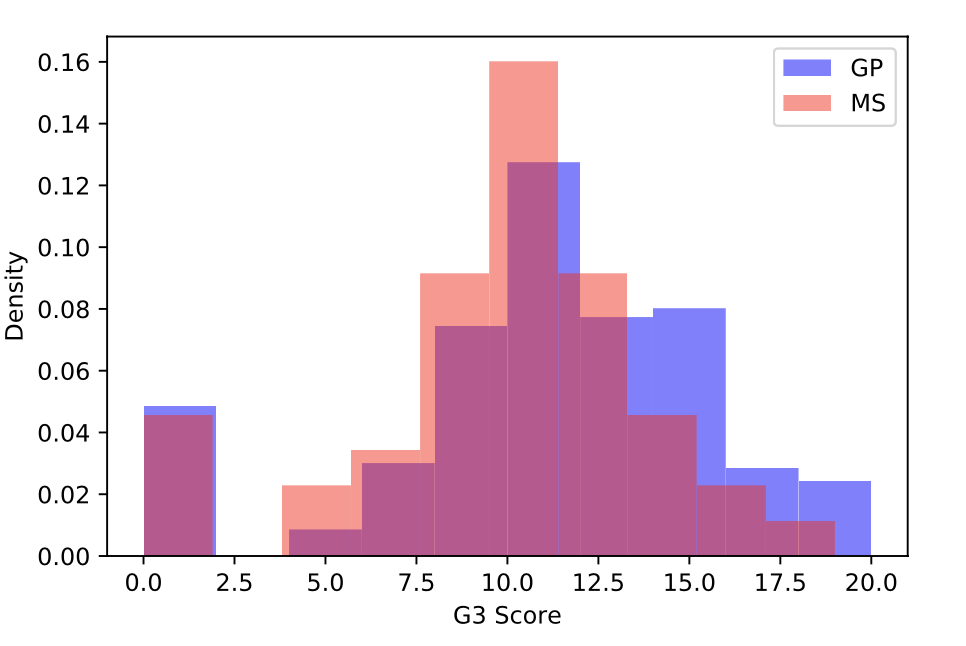

By inspecting this histogram, we can clearly see that the entire distribution of scores at GP (not just the mean or median) appears slightly shifted to the right (higher) compared to the scores at MS.

However, there is also still a lot of overlap between the scores, suggesting that the association is relatively weak.

Note that there are only 46 students at MS, but there are 349 students at GP. If we hadn’t used normed = True, our histogram would have looked like this, making it impossible to compare the distributions fairly:

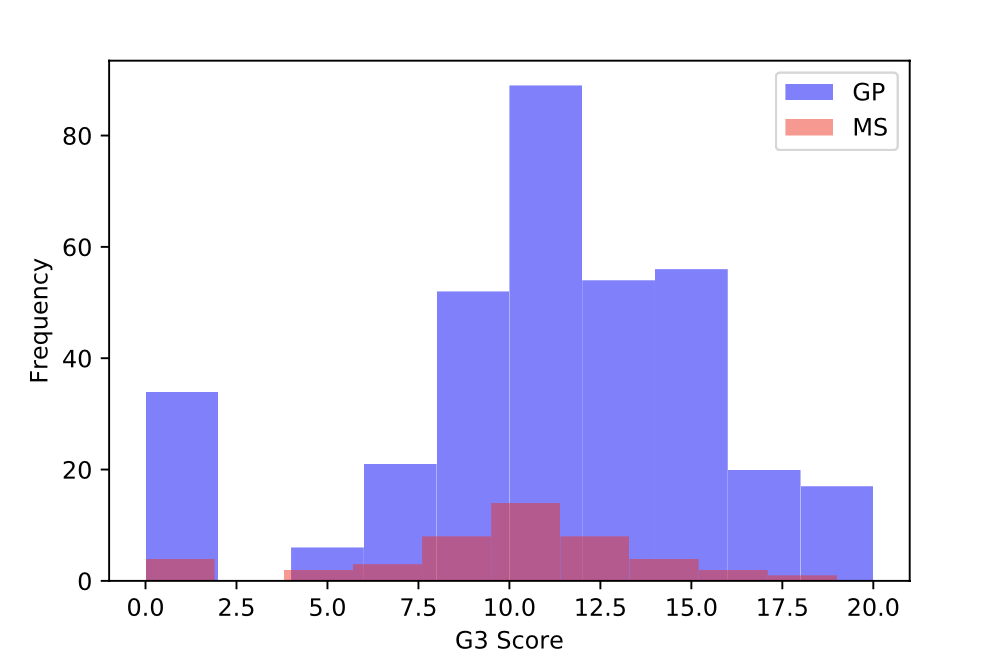

While overlapping histograms and side by side boxplots can convey similar information, histograms give us more detail and can be useful in spotting patterns that were not visible in a box plot (eg., a bimodal distribution).

Example:

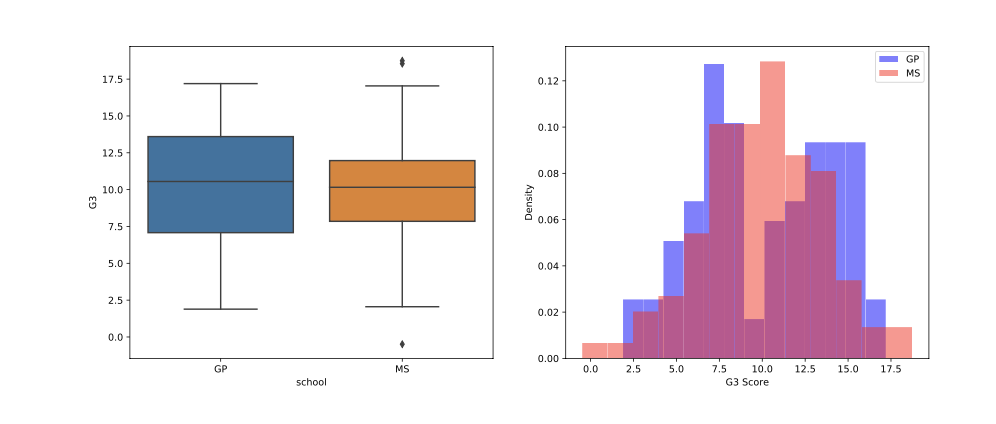

While the box plots and means/medians appear similar, the overlapping histograms illuminate the differences between these two distributions of scores.

## Boxplot: Non-binary Categorical variables

sometimes we are interested in an association between a quantitative variable and non-binary categorical variable. 

Non-binary categorical variables have more than two categories.

When looking at an association between a quantitative variable and a non-binary categorical variable, we must examine all pair-wise differences.

Example:

Suppose we want to know whether or not an association exists between math scores (G3) and (Mjob), a categorical variable representing the mother’s job. This variable has five possible categories: 
* at_home
* health
* services
* teacher
* other 

Let's take a look at the side-by-side boxplot of those 5 different groups:

In [ ]:
import seabron as sns
import matlablib.pyplot as plt

sns.boxplot(
    x="Mjob",
    y="G3",
    data=students
)
plt.show()
plt.close()

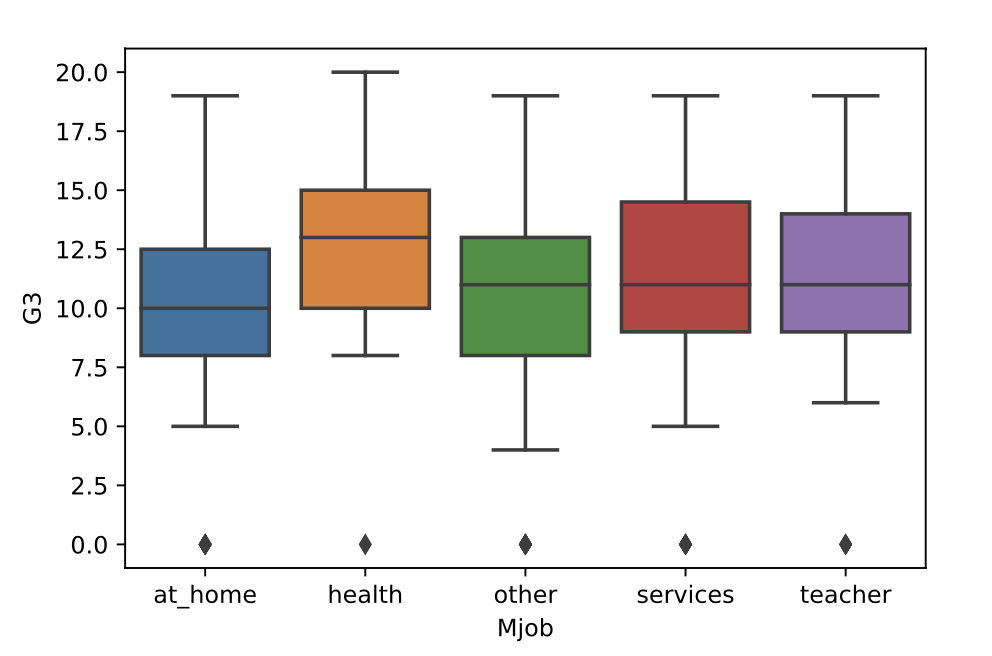

Visually, we need to compare each box to every other box. While most of these boxes overlap with each other, there are some pairs for which there are some apparent differences. 

For example, scores appear to be higher among students with mothers working in health than among students with mothers working at home or in an “other” job. 

If there are ANY pairwise differences, we can say that the variables are associated; however, it is more useful to specifically report which groups are different.